In [2]:
import sys
from pathlib import Path

project_root = Path.cwd().parents[0]  # importing functions from other folders
sys.path.insert(0, str(project_root))

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import os
from _data.data_utils import read_in
from _fitting.fitting_utils import hist_plot, CI_plot, CI_plot_alt, CI_plot_both, plot_posteriors_side_by_side, plot_spline_Bknots
import pymc as pm
import pymc.math as pmm
import arviz as az
from patsy import dmatrix
import nutpie
import time
from IPython.display import display
from pymc.variational.callbacks import CheckParametersConvergence
import io
import base64

az.style.use("arviz-darkgrid")


if '___laptop' in os.listdir('../'):
    # laptop folder
    folder = "../../_data/p-dengue/"
elif '___server' in os.listdir('../'):
    # server folder
    folder = "../../../../../data/lucaratzinger_data/p_dengue/"

Uncovering the effect of different modelling choices for splines

Curve has mean 0.302


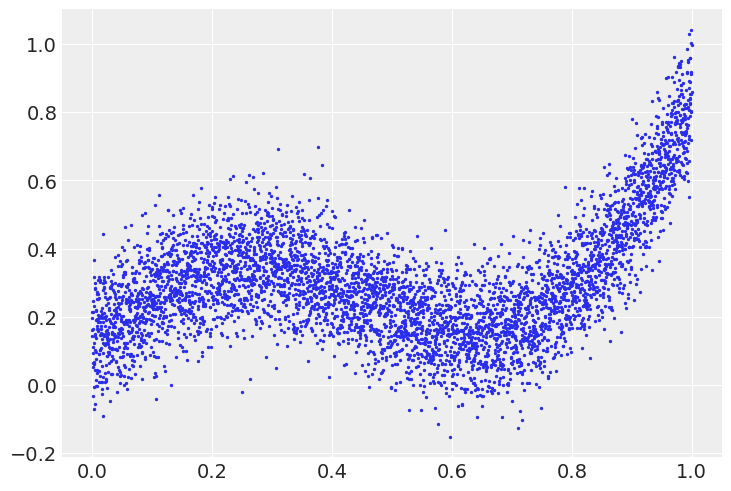

In [2]:
np.random.seed(0)
l = 5000
x = np.linspace(0, 1, l)[::-1]
y = 0.2*np.sin(2 * np.pi * x) + 0.1*np.random.randn(l) + x**3 - 0.5*x**2 + 0.2*x + 0.12
print(f'Curve has mean {y.mean():.3f}')
plt.scatter(x, y, marker='o', label='Data', s=2)
plt.show()

In [3]:
num_knots = 5
degree = 3

---

B_full has shape (5000, 9)
B_drop has shape (5000, 8)


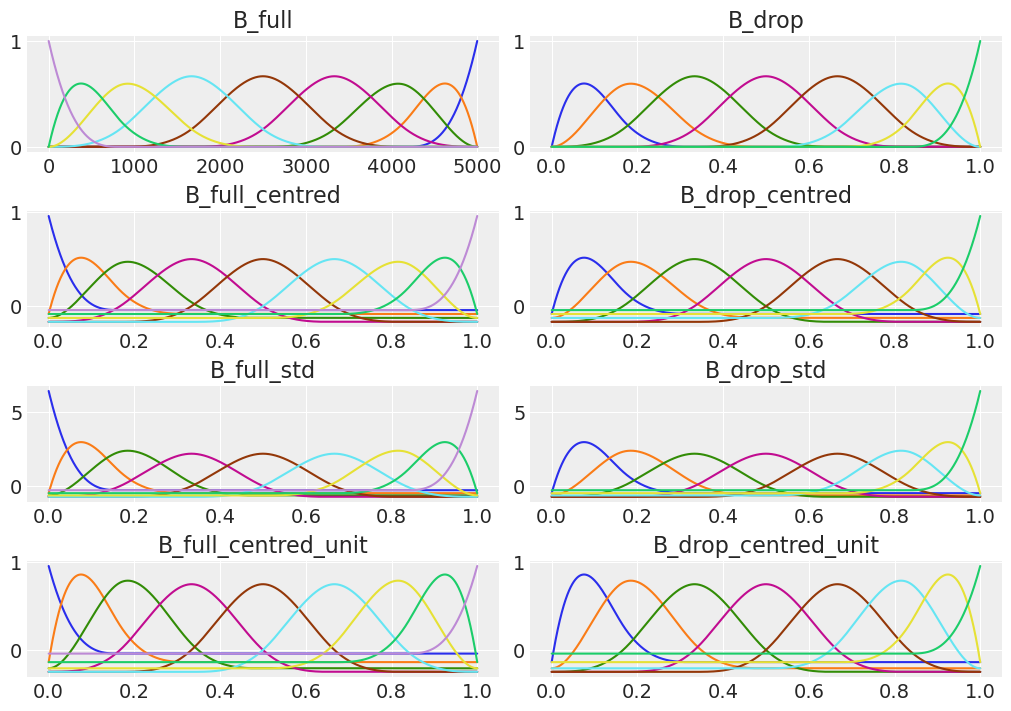

In [4]:
d = x.copy()
knot_list = np.percentile(d, np.linspace(0, 100, num_knots + 2))[1:-1]

B_full = dmatrix(f"bs(s, knots=knots, degree=degree, include_intercept=True)-1",
                {"s": d, "knots": knot_list, "degree":degree})
B_full_centred = B_full - B_full.mean(axis=0)  # centre the spline basis functions
B_full_std = B_full_centred / B_full_centred.std(axis=0)  # standardise the spline basis functions
B_full_centred_unit = B_full_centred / (np.max(B_full_centred, axis=0) - np.min(B_full_centred, axis=0))  # standardise the spline basis functions to unit range
print(f'B_full has shape {B_full.shape}')

B_drop = dmatrix(f"bs(s, knots=knots, degree=degree, include_intercept=False)-1",
                {"s": d, "knots": knot_list, "degree":degree})
B_drop_centred = B_drop - B_drop.mean(axis=0)  # centre the spline basis functions
B_drop_std = B_drop_centred / B_drop_centred.std(axis=0)  # standardise the spline basis functions
B_drop_centred_unit = B_drop_centred / (np.max(B_drop_centred, axis=0) - np.min(B_drop_centred, axis=0))  # standardise the spline basis functions to unit range
print(f'B_drop has shape {B_drop.shape}')


fig, axes = plt.subplots(4, 2, figsize=(10, 7))
ax1 = axes[0, 0]
ax2 = axes[0, 1]
ax3 = axes[1, 0]
ax4 = axes[1, 1]
ax5 = axes[2, 0]
ax6 = axes[2, 1]
ax7 = axes[3, 0]
ax8 = axes[3, 1]

ax1.plot(B_full)
ax1.set_title('B_full')
ax2.plot(x, B_drop)
ax2.set_title('B_drop')
ax3.plot(x, B_full_centred)
ax3.set_title('B_full_centred')
ax4.plot(x, B_drop_centred)
ax4.set_title('B_drop_centred')
ax5.plot(x, B_full_std)
ax5.set_title('B_full_std')
ax7.plot(x, B_full_centred_unit)
ax7.set_title('B_full_centred_unit')
ax8.plot(x, B_drop_centred_unit)
ax8.set_title('B_drop_centred_unit')
ax6.plot(x, B_drop_std)
ax6.set_title('B_drop_std')
plt.show()


B_full has shape (5000, 9)
B_drop has shape (5000, 8)


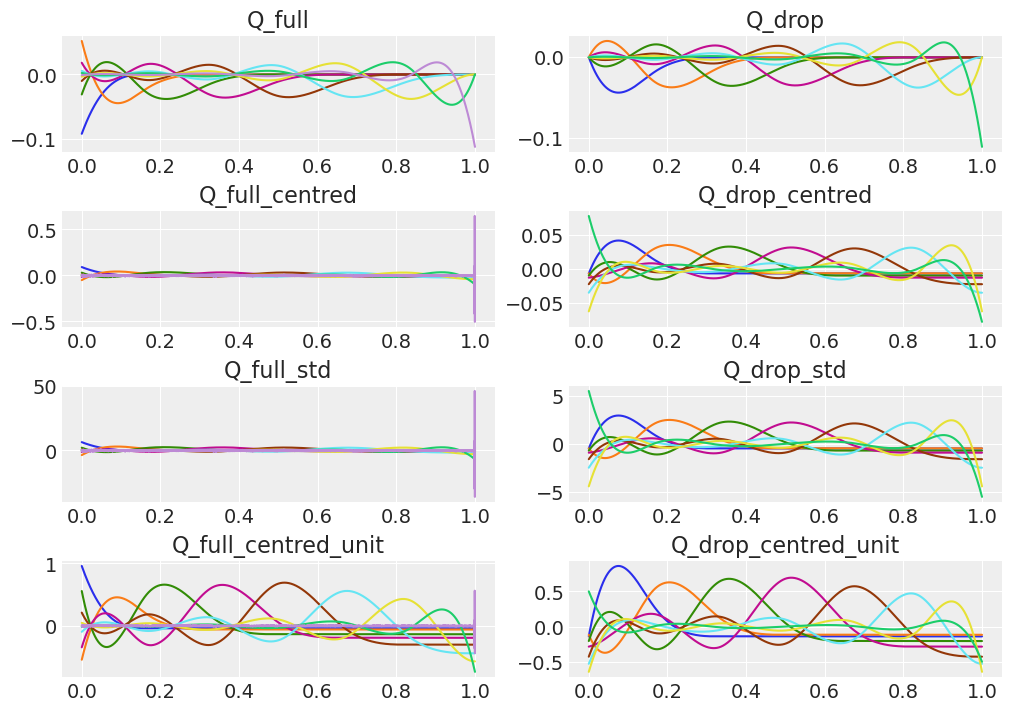

In [5]:
# do the QR decomposition of the spline basis functions to orthogonalise them and plot the Q curves
d = x.copy()
knot_list = np.percentile(d, np.linspace(0, 100, num_knots + 2))[1:-1]

B_full = dmatrix(f"bs(s, knots=knots, degree=degree, include_intercept=True)-1",
                {"s": d, "knots": knot_list, "degree":degree})
Q_full, R_full = np.linalg.qr(B_full)

B_full_centred = B_full - B_full.mean(axis=0)  # centre the spline basis functions
Q_full_centred, R_full_centred = np.linalg.qr(B_full_centred)

Q_full_std = Q_full_centred / Q_full_centred.std(axis=0)  # standardise the spline basis functions

Q_full_centred_unit = Q_full_centred / (np.max(Q_full_centred, axis=0) - np.min(Q_full_centred, axis=0))  # standardise the spline basis functions to unit range
print(f'B_full has shape {B_full.shape}')
###
B_drop = dmatrix(f"bs(s, knots=knots, degree=degree, include_intercept=False)-1",
                {"s": d, "knots": knot_list, "degree":degree})
Q_drop, R_drop = np.linalg.qr(B_drop)

B_drop_centred = B_drop - B_drop.mean(axis=0)  # centre the spline basis functions
Q_drop_centred, R_drop_centred = np.linalg.qr(B_drop_centred)

Q_drop_std = Q_drop_centred / Q_drop_centred.std(axis=0)  # standardise the spline basis functions

Q_drop_centred_unit = Q_drop_centred / (np.max(Q_drop_centred, axis=0) - np.min(Q_drop_centred, axis=0))  # standardise the spline basis functions to unit range
print(f'B_drop has shape {B_drop.shape}')
###

fig, axes = plt.subplots(4, 2, figsize=(10, 7))
ax1 = axes[0, 0]
ax2 = axes[0, 1]
ax3 = axes[1, 0]
ax4 = axes[1, 1]
ax5 = axes[2, 0]
ax6 = axes[2, 1]
ax7 = axes[3, 0]
ax8 = axes[3, 1]

ax1.plot(x, Q_full)
ax1.set_title('Q_full')
ax2.plot(x, Q_drop)
ax2.set_title('Q_drop')
ax3.plot(x, Q_full_centred)
ax3.set_title('Q_full_centred')
ax4.plot(x, Q_drop_centred)
ax4.set_title('Q_drop_centred')
ax5.plot(x, Q_full_std)
ax5.set_title('Q_full_std')
ax7.plot(x, Q_full_centred_unit)
ax7.set_title('Q_full_centred_unit')
ax8.plot(x, Q_drop_centred_unit)
ax8.set_title('Q_drop_centred_unit')
ax6.plot(x, Q_drop_std)
ax6.set_title('Q_drop_std')
plt.show()


---

In [34]:
def fig_to_base64(fig):
    buf = io.BytesIO()
    fig.savefig(buf, format="png", bbox_inches="tight", dpi=150)
    buf.seek(0)
    img_base64 = base64.b64encode(buf.read()).decode("utf-8")
    plt.close(fig)
    return img_base64

def go(m, stat_name='0', var_names=['intercept', 'sigma', 'sigma_w', 'w']):
    with model_dict[m]:
        s0 = time.time()
        idata_dict[m] = pm.sample(
            tune=1000,
            draws=2000,
            chains=4,
            random_seed=4,
            discard_tuned_samples=True,
            nuts_sampler="nutpie",
            store_divergences=True
        )
        s1 = time.time()

        pm.compute_log_likelihood(idata_dict[m], progressbar=False)
        s2 = time.time()

        time_dict[m] = (s1 - s0, s2 - s1)

    # ---------- Summary table ----------
    summary_df = az.summary(idata_dict[m], var_names=var_names)
    summary_html = summary_df.to_html()

    # ---------- Trace plot ----------
    fig_trace = az.plot_trace(idata_dict[m], var_names=var_names)
    fig_trace = fig_trace.ravel()[0].figure
    trace_img = fig_to_base64(fig_trace)

    # ---------- Pair plot ----------
    az.rcParams["plot.max_subplots"] = 200
    ax = az.plot_pair(
        idata_dict[m],
        var_names=var_names,
        textsize=14,
        divergences=True
    )

    for i in range(ax.shape[0]):
        ax[i, 0].yaxis.label.set_rotation(0)
        ax[i, 0].yaxis.label.set_ha('right')

    for j in range(ax.shape[1]):
        ax[0, j].xaxis.label.set_rotation(45)
        ax[0, j].xaxis.label.set_ha('right')

    fig_pair = ax.ravel()[0].figure
    pair_img = fig_to_base64(fig_pair)

    # ---------- Spline plot ----------
    fig_spline = plot_spline_Bknots(
        idata_dict[m],
        stat_name,
        'w',
        'sigma_w',
        B_dict[m],
        x,
        knots=knot_list,
        show_basis=True,
        invert_log=True,
        centred_w=centred_dict[m]
    )
    spline_img = fig_to_base64(fig_spline)

    # ---------- Build HTML ----------
    html_content = f"""
    <html>
    <head>
        <title>Model Report: {m}</title>
        <style>
            body {{ font-family: Arial; margin: 40px; }}
            h1 {{ margin-bottom: 10px; }}
            img {{ margin-top: 20px; max-width: 100%; }}
            table {{ border-collapse: collapse; }}
            th, td {{ padding: 6px 8px; }}
        </style>
    </head>
    <body>
        <h1>Model Report: {m}</h1>

        <h2>Timing</h2>
        <p>Posterior Sampling: {time_dict[m][0]:.2f} seconds</p>
        <p>Log Likelihood Compute: {time_dict[m][1]:.2f} seconds</p>

        <h2>Summary</h2>
        {summary_html}

        <h2>Trace Plot</h2>
        <img src="data:image/png;base64,{trace_img}">

        <h2>Pair Plot</h2>
        <img src="data:image/png;base64,{pair_img}">

        <h2>Spline Plot</h2>
        <img src="data:image/png;base64,{spline_img}">
    </body>
    </html>
    """

    with open(f"{m}.html", "w") as f:
        f.write(html_content)

    print(f"Saved report to {m}.html")


In [7]:
def go_light(m, var_names=['intercept', 'sigma', 'sigma_w', 'w']):
    with model_dict[m]:
        s0 = time.time()
        idata_dict[m] = pm.sample(tune=1000, draws=4000, chains=4, random_seed=4,
                                    discard_tuned_samples=True, nuts_sampler="nutpie", store_divergences=True)
        s1 = time.time()
        pm.compute_log_likelihood(idata_dict[m], progressbar=False)
        s2 = time.time()
        time_dict[m] = (s1 - s0, s2 - s1)
        print(f'Posterior Sampling {s1 - s0:.2f} seconds')
        print(f'Log Likelihood Compute {s2 - s1:.2f} seconds')
        
    var_names = ['intercept', 'sigma', 'sigma_w', 'w']
    display(az.summary(idata_dict[m], var_names=var_names))
    az.plot_trace(idata_dict[m], var_names=var_names);

    plot_spline_Bknots(idata_dict[m], 'tp', 'w', 'sigma_w',
            B_dict[m], x,
            knots=knot_list,
            show_basis=True, basis_scale=8, invert_log=False);
    # 0.01
    var_names = ['intercept', 'sigma', 'sigma_w', 'w']
    az.rcParams["plot.max_subplots"] = 200
    ax = az.plot_pair(idata_dict[m], var_names=var_names, textsize=20, divergences=True)

    for i in range(ax.shape[0]):
        # Left-hand side (row labels / y-axis labels)
        ax[i, 0].yaxis.label.set_rotation(0)  # e.g., vertical left labels
        ax[i, 0].yaxis.label.set_ha('right')  # horizontal alignment

    for j in range(ax.shape[1]):
        # Top (column labels / x-axis labels)
        ax[0, j].xaxis.label.set_rotation(45)  # e.g., rotate top labels
        ax[0, j].xaxis.label.set_ha('right')

In [8]:
def compare_models(models_list, iter):
    # Compare models
    times = {m: [] for m in models_list}
    for m in models_list:
        for i in range(iter):
            with model_dict[m]:
                s0 = time.time()
                idata_dict[m] = pm.sample(tune=1000, draws=1500, chains=4, progressbar=False,
                                            discard_tuned_samples=True, nuts_sampler="nutpie", store_divergences=True)
                s1 = time.time()
                pm.compute_log_likelihood(idata_dict[m], progressbar=False)
                s2 = time.time()
                times[m].append(s1 - s0)
        print(f"Model {m}: Mean time = {np.mean(times[m]):.2f} seconds")
    mean_times = {m: np.mean(times[m]) for m in models_list}
    return times, mean_times 

In [9]:
model_dict = {}
B_dict = {}
idata_dict = {}
time_dict = {}
centred_dict = {}

---

## Models

In [10]:
m = "B_full_centred_unit, sigma_w sd = 0.5"

model = pm.Model()
with model:
    # Priors
    sigma = pm.HalfNormal("sigma", sigma=0.5)
    intercept = pm.Normal("intercept", mu=0, sigma=2.0)

    # Spline coefficients
    sigma_w = pm.HalfNormal(f"sigma_w", sigma=0.5)

    w = pm.Normal(f"w", mu=0, sigma=sigma_w, shape=B_full_centred_unit.shape[1], dims='splines')
    f = pm.math.dot(B_full_centred_unit, w)

    mu = intercept + f

    # Likelihood
    y_obs = pm.Normal('y_obs', mu=mu, sigma=sigma, observed=y)

model_dict[m] = model
centred_dict[m] = True
B_dict[m] = B_full_centred_unit

m = "B_full_centred_unit, sigma_w sd = 0.25"

model = pm.Model()
with model:
    # Priors
    sigma = pm.HalfNormal("sigma", sigma=0.5)
    intercept = pm.Normal("intercept", mu=0, sigma=2.0)

    # Spline coefficients
    sigma_w = pm.HalfNormal(f"sigma_w", sigma=0.25)

    w = pm.Normal(f"w", mu=0, sigma=sigma_w, shape=B_full_centred_unit.shape[1], dims='splines')
    f = pm.math.dot(B_full_centred_unit, w)

    mu = intercept + f

    # Likelihood
    y_obs = pm.Normal('y_obs', mu=mu, sigma=sigma, observed=y)

model_dict[m] = model
centred_dict[m] = True
B_dict[m] = B_full_centred_unit

m = "B_full_centred, sigma_w sd = 0.5"

model = pm.Model()
with model:
    # Priors
    sigma = pm.HalfNormal("sigma", sigma=0.5)
    intercept = pm.Normal("intercept", mu=0, sigma=2.0)

    # Spline coefficients
    sigma_w = pm.HalfNormal(f"sigma_w", sigma=0.5)

    w = pm.Normal(f"w", mu=0, sigma=sigma_w, shape=B_full_centred.shape[1], dims='splines')
    f = pm.math.dot(B_full_centred, w)

    mu = intercept + f

    # Likelihood
    y_obs = pm.Normal('y_obs', mu=mu, sigma=sigma, observed=y)

model_dict[m] = model
centred_dict[m] = True
B_dict[m] = B_full_centred

m = "B_full_centred, sigma_w sd = 0.25"

model = pm.Model()
with model:
    # Priors
    sigma = pm.HalfNormal("sigma", sigma=0.5)
    intercept = pm.Normal("intercept", mu=0, sigma=2.0)

    # Spline coefficients
    sigma_w = pm.HalfNormal(f"sigma_w", sigma=0.25)

    w = pm.Normal(f"w", mu=0, sigma=sigma_w, shape=B_full_centred.shape[1], dims='splines')
    f = pm.math.dot(B_full_centred, w)

    mu = intercept + f

    # Likelihood
    y_obs = pm.Normal('y_obs', mu=mu, sigma=sigma, observed=y)

model_dict[m] = model
centred_dict[m] = True
B_dict[m] = B_full_centred

m = "B_drop_centred_unit, sigma_w sd = 0.5"

model = pm.Model()
with model:
    # Priors
    sigma = pm.HalfNormal("sigma", sigma=0.5)
    intercept = pm.Normal("intercept", mu=0, sigma=2.0)

    # Spline coefficients
    sigma_w = pm.HalfNormal(f"sigma_w", sigma=0.5)

    w = pm.Normal(f"w", mu=0, sigma=sigma_w, shape=B_drop_centred_unit.shape[1], dims='splines')
    f = pm.math.dot(B_drop_centred_unit, w)

    mu = intercept + f

    # Likelihood
    y_obs = pm.Normal('y_obs', mu=mu, sigma=sigma, observed=y)

model_dict[m] = model
centred_dict[m] = True
B_dict[m] = B_drop_centred_unit

m = "B_drop_centred_unit, sigma_w sd = 0.25"

model = pm.Model()
with model:
    # Priors
    sigma = pm.HalfNormal("sigma", sigma=0.5)
    intercept = pm.Normal("intercept", mu=0, sigma=2.0)

    # Spline coefficients
    sigma_w = pm.HalfNormal(f"sigma_w", sigma=0.25)

    w = pm.Normal(f"w", mu=0, sigma=sigma_w, shape=B_drop_centred_unit.shape[1], dims='splines')
    f = pm.math.dot(B_drop_centred_unit, w)

    mu = intercept + f

    # Likelihood
    y_obs = pm.Normal('y_obs', mu=mu, sigma=sigma, observed=y)

model_dict[m] = model
centred_dict[m] = True
B_dict[m] = B_drop_centred_unit

m = "B_drop_centred, sigma_w sd = 0.5"

model = pm.Model()
with model:
    # Priors
    sigma = pm.HalfNormal("sigma", sigma=0.5)
    intercept = pm.Normal("intercept", mu=0, sigma=2.0)

    # Spline coefficients
    sigma_w = pm.HalfNormal(f"sigma_w", sigma=0.5)

    w = pm.Normal(f"w", mu=0, sigma=sigma_w, shape=B_drop_centred.shape[1], dims='splines')
    f = pm.math.dot(B_drop_centred, w)

    mu = intercept + f

    # Likelihood
    y_obs = pm.Normal('y_obs', mu=mu, sigma=sigma, observed=y)

model_dict[m] = model
centred_dict[m] = True
B_dict[m] = B_drop_centred

m = "B_drop_centred, sigma_w sd = 0.25"

model = pm.Model()
with model:
    # Priors
    sigma = pm.HalfNormal("sigma", sigma=0.5)
    intercept = pm.Normal("intercept", mu=0, sigma=2.0)

    # Spline coefficients
    sigma_w = pm.HalfNormal(f"sigma_w", sigma=0.25)

    w = pm.Normal(f"w", mu=0, sigma=sigma_w, shape=B_drop_centred.shape[1], dims='splines')
    f = pm.math.dot(B_drop_centred, w)

    mu = intercept + f

    # Likelihood
    y_obs = pm.Normal('y_obs', mu=mu, sigma=sigma, observed=y)

model_dict[m] = model
centred_dict[m] = True
B_dict[m] = B_drop_centred

In [11]:
m = "Q_drop_centred, sigma_w sd = 0.5"

model = pm.Model()
with model:
    # Priors
    sigma = pm.HalfNormal("sigma", sigma=0.5)
    intercept = pm.Normal("intercept", mu=0, sigma=2.0)

    # Spline coefficients
    sigma_w = pm.HalfNormal(f"sigma_w", sigma=0.5)

    w = pm.Normal(f"w", mu=0, sigma=sigma_w, shape=Q_drop_centred.shape[1], dims='splines')
    f = pm.math.dot(Q_drop_centred, w)

    mu = intercept + f

    # Likelihood
    y_obs = pm.Normal('y_obs', mu=mu, sigma=sigma, observed=y)

model_dict[m] = model
centred_dict[m] = True
B_dict[m] = Q_drop_centred

m = "Q_drop_centred, sigma_w sd = 0.25"

model = pm.Model()
with model:
    # Priors
    sigma = pm.HalfNormal("sigma", sigma=0.5)
    intercept = pm.Normal("intercept", mu=0, sigma=2.0)

    # Spline coefficients
    sigma_w = pm.HalfNormal(f"sigma_w", sigma=0.25)

    w = pm.Normal(f"w", mu=0, sigma=sigma_w, shape=Q_drop_centred.shape[1], dims='splines')
    f = pm.math.dot(Q_drop_centred, w)

    mu = intercept + f

    # Likelihood
    y_obs = pm.Normal('y_obs', mu=mu, sigma=sigma, observed=y)

model_dict[m] = model
centred_dict[m] = True
B_dict[m] = Q_drop_centred

m = "Q_drop_centred_unit, sigma_w sd = 0.5"

model = pm.Model()
with model:
    # Priors
    sigma = pm.HalfNormal("sigma", sigma=0.5)
    intercept = pm.Normal("intercept", mu=0, sigma=2.0)

    # Spline coefficients
    sigma_w = pm.HalfNormal(f"sigma_w", sigma=0.5)

    w = pm.Normal(f"w", mu=0, sigma=sigma_w, shape=Q_drop_centred_unit.shape[1], dims='splines')
    f = pm.math.dot(Q_drop_centred_unit, w)

    mu = intercept + f

    # Likelihood
    y_obs = pm.Normal('y_obs', mu=mu, sigma=sigma, observed=y)

model_dict[m] = model
centred_dict[m] = True
B_dict[m] = Q_drop_centred_unit

m = "Q_drop_centred_unit, sigma_w sd = 0.25"

model = pm.Model()
with model:
    # Priors
    sigma = pm.HalfNormal("sigma", sigma=0.5)
    intercept = pm.Normal("intercept", mu=0, sigma=2.0)

    # Spline coefficients
    sigma_w = pm.HalfNormal(f"sigma_w", sigma=0.25)

    w = pm.Normal(f"w", mu=0, sigma=sigma_w, shape=Q_drop_centred_unit.shape[1], dims='splines')
    f = pm.math.dot(Q_drop_centred_unit, w)

    mu = intercept + f

    # Likelihood
    y_obs = pm.Normal('y_obs', mu=mu, sigma=sigma, observed=y)

model_dict[m] = model
centred_dict[m] = True
B_dict[m] = Q_drop_centred_unit

1) standard spline B_full w

In [12]:
m = "B_full, sigma_w sd = 0.5 (non-centred parametrisation)"

model = pm.Model()
with model:
    # Priors
    sigma = pm.HalfNormal("sigma", sigma=0.5)
    intercept = pm.Normal("intercept", mu=0, sigma=2.5)

    # Spline coefficients
    sigma_w = pm.HalfNormal(f"sigma_w", sigma=0.5)

    w = pm.Normal(f"w", mu=0, sigma=1, shape=B_full.shape[1], dims='splines')
    f = pm.math.dot(B_full, sigma_w*w)

    mu = intercept + f

    # Likelihood
    y_obs = pm.Normal('y_obs', mu=mu, sigma=sigma, observed=y)

model_dict[m] = model
centred_dict[m] = False
B_dict[m] = B_full

In [13]:
m = "B_full_centred, sigma_w sd = 0.5 (non-centred parametrisation)"

model = pm.Model()
with model:
    # Priors
    sigma = pm.HalfNormal("sigma", sigma=0.5)
    intercept = pm.Normal("intercept", mu=0, sigma=2.5)

    # Spline coefficients
    sigma_w = pm.HalfNormal(f"sigma_w", sigma=0.5)

    w = pm.Normal(f"w", mu=0, sigma=1, shape=B_full_centred.shape[1], dims='splines')
    f = pm.math.dot(B_full_centred, sigma_w*w)

    mu = intercept + f

    # Likelihood
    y_obs = pm.Normal('y_obs', mu=mu, sigma=sigma, observed=y)

model_dict[m] = model
centred_dict[m] = False
B_dict[m] = B_full_centred

In [14]:
m = "B_full_std, sigma_w sd = 0.5 (non-centred parametrisation)"

model = pm.Model()
with model:
    # Priors
    sigma = pm.HalfNormal("sigma", sigma=0.5)
    intercept = pm.Normal("intercept", mu=0, sigma=2.5)

    # Spline coefficients
    sigma_w = pm.HalfNormal(f"sigma_w", sigma=0.5)

    w = pm.Normal(f"w", mu=0, sigma=1, shape=B_full.shape[1], dims='splines')
    f = pm.math.dot(B_full_std, sigma_w*w)

    mu = intercept + f

    # Likelihood
    y_obs = pm.Normal('y_obs', mu=mu, sigma=sigma, observed=y)

model_dict[m] = model
centred_dict[m] = False
B_dict[m] = B_full_std

In [15]:
m = "B_full_centred_unit, sigma_w sd = 0.25 (non-centred parametrisation)"
model = pm.Model()
with model:
    # Priors
    sigma = pm.HalfNormal("sigma", sigma=0.5)
    intercept = pm.Normal("intercept", mu=0, sigma=2.5)

    # Spline coefficients
    sigma_w = pm.HalfNormal(f"sigma_w", sigma=0.25)

    w = pm.Normal(f"w", mu=0, sigma=1, shape=B_full_centred_unit.shape[1], dims='splines')
    f = pm.math.dot(B_full_centred_unit, sigma_w*w)

    mu = intercept + f

    # Likelihood
    y_obs = pm.Normal('y_obs', mu=mu, sigma=sigma, observed=y)

model_dict[m] = model
centred_dict[m] = False
B_dict[m] = B_full_centred_unit

In [16]:
m = "B_full_centred_unit, sigma_w sd = 0.5 (centred parametrisation)"
model = pm.Model()
with model:
    # Priors
    sigma = pm.HalfNormal("sigma", sigma=0.5)
    intercept = pm.Normal("intercept", mu=0, sigma=2.5)

    # Spline coefficients
    sigma_w = pm.HalfNormal(f"sigma_w", sigma=0.5)

    w = pm.Normal(f"w", mu=0, sigma=sigma_w, shape=B_full_centred_unit.shape[1], dims='splines')
    f = pm.math.dot(B_full_centred_unit, w)

    mu = intercept + f

    # Likelihood
    y_obs = pm.Normal('y_obs', mu=mu, sigma=sigma, observed=y)

model_dict[m] = model
centred_dict[m] = True
B_dict[m] = B_full_centred_unit

In [17]:
m = "B_drop_centred_unit, sigma_w sd = 0.5 (centred parametrisation)"
model = pm.Model()
with model:
    # Priors
    sigma = pm.HalfNormal("sigma", sigma=0.5)
    intercept = pm.Normal("intercept", mu=0, sigma=2.5)

    # Spline coefficients
    sigma_w = pm.HalfNormal(f"sigma_w", sigma=0.5)

    w = pm.Normal(f"w", mu=0, sigma=sigma_w, shape=B_drop_centred_unit.shape[1], dims='splines')
    f = pm.math.dot(B_drop_centred_unit, w)

    mu = intercept + f

    # Likelihood
    y_obs = pm.Normal('y_obs', mu=mu, sigma=sigma, observed=y)

model_dict[m] = model
centred_dict[m] = True
B_dict[m] = B_drop_centred_unit

In [18]:
m = "B_drop_centred_unit, sigma_w sd = 0.25 (non-centred parametrisation)"
model = pm.Model()
with model:
    # Priors
    sigma = pm.HalfNormal("sigma", sigma=0.5)
    intercept = pm.Normal("intercept", mu=0, sigma=2.5)

    # Spline coefficients
    sigma_w = pm.HalfNormal(f"sigma_w", sigma=0.25)

    w = pm.Normal(f"w", mu=0, sigma=1, shape=B_drop_centred_unit.shape[1], dims='splines')
    f = pm.math.dot(B_drop_centred_unit, sigma_w*w)

    mu = intercept + f

    # Likelihood
    y_obs = pm.Normal('y_obs', mu=mu, sigma=sigma, observed=y)
    
model_dict[m] = model
centred_dict[m] = False
B_dict[m] = B_drop_centred_unit

naive implementation has high correlation within spline weights and correlation between weights and intercept + funnel behaviour

---

2) B_drop w
will removing the splines' ability to create a constant function remove correlation with intercept?

In [19]:
m = "B_drop, sigma_w sd = 0.5 (non-centred parametrisation)"

model = pm.Model()
with model:
    # Priors
    sigma = pm.HalfNormal("sigma", sigma=0.5)
    intercept = pm.Normal("intercept", mu=0, sigma=2.5)

    # Spline coefficients
    sigma_w = pm.HalfNormal(f"sigma_w", sigma=0.5)

    w = pm.Normal(f"w", mu=0, sigma=1, shape=B_drop.shape[1], dims='splines')
    f = pm.math.dot(B_drop, sigma_w*w)

    mu = intercept + f

    # Likelihood
    y_obs = pm.Normal('y_obs', mu=mu, sigma=sigma, observed=y)

model_dict[m] = model
centred_dict[m] = False
B_dict[m] = B_drop

is removing correlation with intercept but correlation withing weights is stronger and also between weights and sigma_w.

---

3) B_full w
with soft mean zero constraint on f to remove correlation with intercept. constraint is naive on B w before multiplying by sigma_w

In [20]:
m = "B_full, sigma_w sd = 0.5 (non-centred parametrisation, soft constraint)"

model = pm.Model()
with model:
    # Priors
    sigma = pm.HalfNormal("sigma", sigma=0.5)
    intercept = pm.Normal("intercept", mu=0, sigma=2.5)

    # Spline coefficients
    sigma_w = pm.HalfNormal(f"sigma_w", sigma=0.5)

    w = pm.Normal(f"w", mu=0, sigma=1, shape=B_full.shape[1], dims='splines')
    f_raw = pm.math.dot(B_full, w)
    f_mean = pm.math.mean(f_raw)
    pm.Potential(f"f_centred_prior", pm.logp(pm.Normal.dist(mu=0.0, sigma=0.01), f_mean))
    f = pm.math.dot(B_full, sigma_w*w)

    mu = intercept + f

    # Likelihood
    y_obs = pm.Normal('y_obs', mu=mu, sigma=sigma, observed=y)

model_dict[m] = model
centred_dict[m] = False
B_dict[m] = B_full

kind of solves intercept correlation though it is a bit weird, sigma_w and weights correlation strong (stronger than naive implementation even though sigma_w is outside of constraint), within weights still strong.

---

4) scaled soft mean zero constraint

In [21]:
m = "B_full, sigma_w sd = 0.5 (non-centred parametrisation, soft range-scaled constraint)"
model = pm.Model()
with model:
    # Priors
    sigma = pm.HalfNormal("sigma", sigma=0.5)
    intercept = pm.Normal("intercept", mu=0, sigma=2.5)

    # Spline coefficients
    sigma_w = pm.HalfNormal(f"sigma_w", sigma=0.5)

    w = pm.Normal(f"w", mu=0, sigma=1, shape=B_full.shape[1], dims='splines')
    f_raw = pm.math.dot(B_full, w)
    f_mean = pm.math.mean(f_raw)
    f_min = pm.math.min(f_raw)
    f_max = pm.math.max(f_raw)
    pm.Potential(f"f_centred_prior", pm.logp(pm.Normal.dist(mu=0.0, sigma=0.01), f_mean/(f_max - f_min)))
    f = pm.math.dot(B_full, sigma_w*w)

    mu = intercept + f

    # Likelihood
    y_obs = pm.Normal('y_obs', mu=mu, sigma=sigma, observed=y)

model_dict[m] = model
centred_dict[m] = False
B_dict[m] = B_full

slightly better correlations but not much of an improvement.

---

5) B_drop + hard constraint

B_drop means basis does not span constant vectors, and we have seen this removes intercept correlation. Hard constraint? not sure if it will be better or worse

In [22]:
m = "B_drop, sigma_w sd = 0.5 (non-centred parametrisation, hard constraint)"

model = pm.Model()
with model:
    # Priors
    sigma = pm.HalfNormal("sigma", sigma=0.5)
    intercept = pm.Normal("intercept", mu=0, sigma=2.5)

    # Spline coefficients
    sigma_w = pm.HalfNormal(f"sigma_w", sigma=0.5)

    w = pm.Normal(f"w", mu=0, sigma=1, shape=B_drop.shape[1], dims='splines')
    f_raw = pm.math.dot(B_drop, sigma_w*w)
    f = f_raw - pm.math.mean(f_raw)  # centre the spline function

    mu = intercept + f

    # Likelihood
    y_obs = pm.Normal('y_obs', mu=mu, sigma=sigma, observed=y)

model_dict[m] = model
centred_dict[m] = False
B_dict[m] = B_drop

similar correlations to simple B_drop. seems to have more divergences.

---

In [23]:
ml = list(model_dict.keys())
print(len(ml))
ml.sort()
ml

23


['B_drop, sigma_w sd = 0.5 (non-centred parametrisation)',
 'B_drop, sigma_w sd = 0.5 (non-centred parametrisation, hard constraint)',
 'B_drop_centred, sigma_w sd = 0.25',
 'B_drop_centred, sigma_w sd = 0.5',
 'B_drop_centred_unit, sigma_w sd = 0.25',
 'B_drop_centred_unit, sigma_w sd = 0.25 (non-centred parametrisation)',
 'B_drop_centred_unit, sigma_w sd = 0.5',
 'B_drop_centred_unit, sigma_w sd = 0.5 (centred parametrisation)',
 'B_full, sigma_w sd = 0.5 (non-centred parametrisation)',
 'B_full, sigma_w sd = 0.5 (non-centred parametrisation, soft constraint)',
 'B_full, sigma_w sd = 0.5 (non-centred parametrisation, soft range-scaled constraint)',
 'B_full_centred, sigma_w sd = 0.25',
 'B_full_centred, sigma_w sd = 0.5',
 'B_full_centred, sigma_w sd = 0.5 (non-centred parametrisation)',
 'B_full_centred_unit, sigma_w sd = 0.25',
 'B_full_centred_unit, sigma_w sd = 0.25 (non-centred parametrisation)',
 'B_full_centred_unit, sigma_w sd = 0.5',
 'B_full_centred_unit, sigma_w sd = 0.5 

In [24]:
len(list(centred_dict.keys()))

23

In [25]:
ml =[]

In [26]:
from IPython.utils.capture import capture_output
for m in ml:
    print(f"Running model: {m}")
    with capture_output():
        go(m)

---

---
Trying on real data and model

In [27]:
data = read_in(folder, admin=2, max_lag=6, dropna=True, end_year=2017, end_month=12)
data.columns
data.shape

(11886, 160)

In [28]:
y = data['cases'].values
data_label = ['tp_24hmean_pop_weighted_log(1)',
     'tp_24hmean_pop_weighted_log(5)',
     'rh_mean_pop_weighted(0)',
     't2m_mean_pop_weighted(0)']
p = data['population'].values

# id = np.argsort(x)
# x = x[id]
# y = y[id]
# p = p[id]

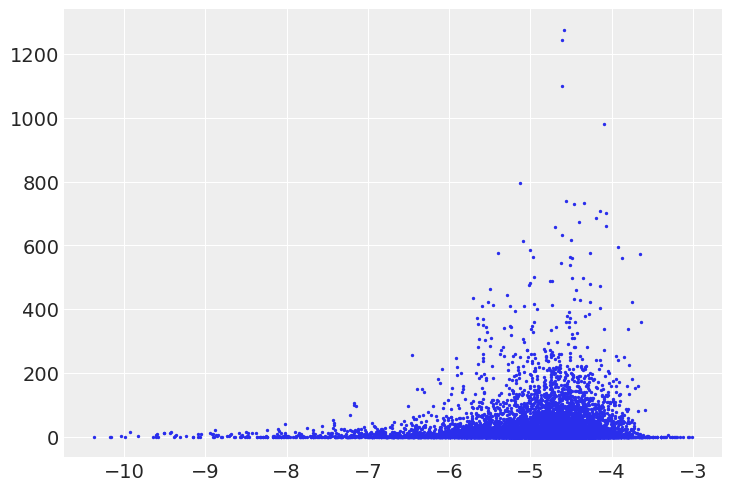

Progress,Draws,Divergences,Step Size,Gradients/Draw
,3000,0,0.39,15
,3000,0,0.32,15
,3000,0,0.33,7
,3000,0,0.36,15


Saved report to B_drop_centred_unit, sigma_w sd = 0.25 NB (tp_24hmean_pop_weighted_log(1)).html


Progress,Draws,Divergences,Step Size,Gradients/Draw
,3000,0,0.83,7
,3000,0,0.91,7
,3000,0,0.87,7
,3000,0,0.83,3


Saved report to Q_drop_centred_unit, sigma_w sd = 0.25 NB (tp_24hmean_pop_weighted_log(1)).html


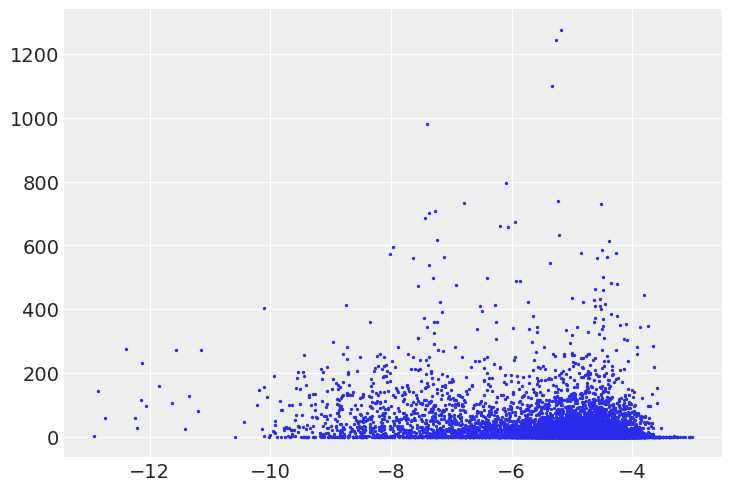

Progress,Draws,Divergences,Step Size,Gradients/Draw
,3000,0,0.36,31
,3000,0,0.41,7
,3000,0,0.42,7
,3000,0,0.39,15


Saved report to B_drop_centred_unit, sigma_w sd = 0.25 NB (tp_24hmean_pop_weighted_log(5)).html


Progress,Draws,Divergences,Step Size,Gradients/Draw
,3000,0,0.77,7
,3000,0,0.76,7
,3000,0,0.85,7
,3000,0,0.71,7


Saved report to Q_drop_centred_unit, sigma_w sd = 0.25 NB (tp_24hmean_pop_weighted_log(5)).html


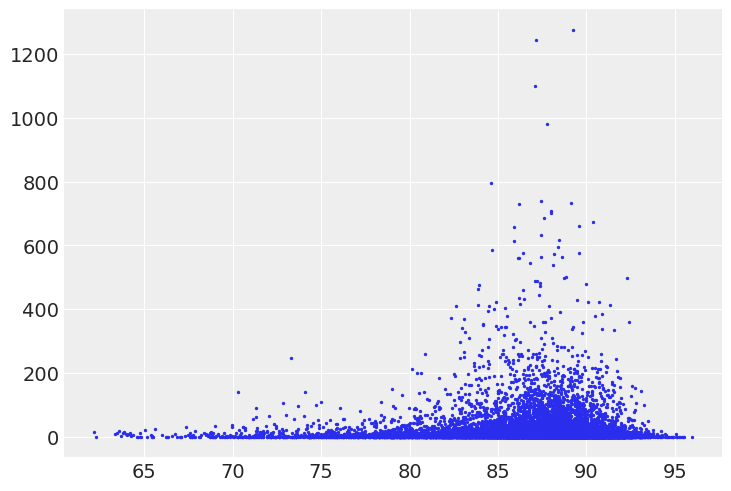

Progress,Draws,Divergences,Step Size,Gradients/Draw
,3000,0,0.34,15
,3000,0,0.33,7
,3000,0,0.39,47
,3000,0,0.36,47


Saved report to B_drop_centred_unit, sigma_w sd = 0.25 NB (rh_mean_pop_weighted(0)).html


Progress,Draws,Divergences,Step Size,Gradients/Draw
,3000,0,0.73,7
,3000,0,0.84,3
,3000,0,0.75,7
,3000,0,0.76,7


Saved report to Q_drop_centred_unit, sigma_w sd = 0.25 NB (rh_mean_pop_weighted(0)).html


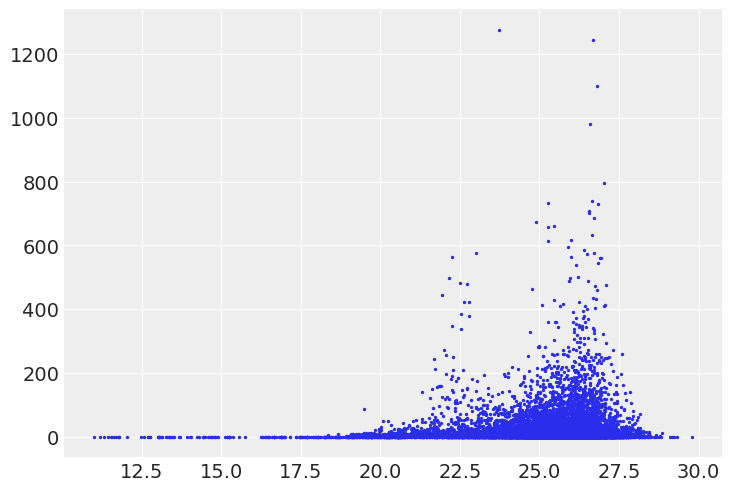

Progress,Draws,Divergences,Step Size,Gradients/Draw
,3000,0,0.28,31
,3000,0,0.25,31
,3000,0,0.29,15
,3000,0,0.27,23


Saved report to B_drop_centred_unit, sigma_w sd = 0.25 NB (t2m_mean_pop_weighted(0)).html


Progress,Draws,Divergences,Step Size,Gradients/Draw
,3000,0,0.75,7
,3000,0,0.76,7
,3000,0,0.72,7
,3000,0,0.79,7


Saved report to Q_drop_centred_unit, sigma_w sd = 0.25 NB (t2m_mean_pop_weighted(0)).html


In [35]:
for l in data_label:
    x = data[l].values
    plt.scatter(x, y, marker='o', label='Data', s=2)
    plt.show()

    d = x.copy()
    knot_list = np.percentile(d, np.linspace(0, 100, num_knots + 2))[1:-1]

    B_drop = dmatrix(f"bs(s, knots=knots, degree=degree, include_intercept=False)-1",
                    {"s": d, "knots": knot_list, "degree":degree})
    B_drop_centred = B_drop - B_drop.mean(axis=0)  # centre the spline basis functions
    B_drop_std = B_drop_centred / B_drop_centred.std(axis=0)  # standardise the spline basis functions
    B_drop_centred_unit = B_drop_centred / (np.max(B_drop_centred, axis=0) - np.min(B_drop_centred, axis=0))  # standardise the spline basis functions to unit range

    Q_drop_centred, R_drop_centred = np.linalg.qr(B_drop_centred)
    Q_drop_std = Q_drop_centred / Q_drop_centred.std(axis=0)  # standardise the spline basis functions
    Q_drop_centred_unit = Q_drop_centred / (np.max(Q_drop_centred, axis=0) - np.min(Q_drop_centred, axis=0))  # standardise the spline basis functions to unit range

    m = f"B_drop_centred_unit, sigma_w sd = 0.25 NB ({l})"

    model = pm.Model()
    with model:
        # Priors
        alpha = pm.Exponential("sigma", 0.5)
        intercept = pm.Normal("intercept", mu=0, sigma=2.5)

        # Spline coefficients
        sigma_w = pm.HalfNormal(f"sigma_w", sigma=0.25)

        w = pm.Normal(f"w", mu=0, sigma=sigma_w, shape=B_drop_centred_unit.shape[1], dims='splines')
        f = pm.math.dot(B_drop_centred_unit, w)

        log_mu = intercept + pm.math.log(p)
        log_mu += f

        # Likelihood
        y_obs = pm.NegativeBinomial('y_obs', mu=pm.math.exp(log_mu), alpha=alpha, observed=y)

    model_dict[m] = model
    centred_dict[m] = True
    B_dict[m] = B_drop_centred_unit

    go(m, stat_name=l)

    m = f"Q_drop_centred_unit, sigma_w sd = 0.25 NB ({l})"

    model = pm.Model()
    with model:
        # Priors
        alpha = pm.Exponential("sigma", 0.5)
        intercept = pm.Normal("intercept", mu=0, sigma=2.5)

        # Spline coefficients
        sigma_w = pm.HalfNormal(f"sigma_w", sigma=0.25)

        w = pm.Normal(f"w", mu=0, sigma=sigma_w, shape=Q_drop_centred_unit.shape[1], dims='splines')
        f = pm.math.dot(Q_drop_centred_unit, w)

        log_mu = intercept + pm.math.log(p)
        log_mu += f

        # Likelihood
        y_obs = pm.NegativeBinomial('y_obs', mu=pm.math.exp(log_mu), alpha=alpha, observed=y)

    model_dict[m] = model
    centred_dict[m] = True
    B_dict[m] = Q_drop_centred_unit

    go(m, stat_name = l)

